In [1]:
import numpy as np
import meshio
import meshplot as mp
import matplotlib as mpl
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


In [2]:
def load_off(fname):
    mesh = meshio.read(fname)
    V = np.asarray(mesh.points)
    F = np.asarray(mesh.cells_dict["triangle"])
    return V, F


def load_error(err_fname):
    err = np.loadtxt(err_fname)
    return err


def error_to_colors(err, vmin=0.0, vmax=0.0008, cmap_name="RdYlBu_r"):
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = mpl.colormaps[cmap_name]
    vertex_colors = cmap(norm(err))[:, :3]
    return vertex_colors


def gray_colors(n_vertices, gray_value=0.95):
    return np.tile(np.array([[gray_value, gray_value, gray_value]]), (n_vertices, 1))

In [3]:
#File names:
true_off = "elephant_40_baseline_v0_test_true.off"

baseline_pred_off = "elephant_40_baseline_v0_test_pred.off"
baseline_err_txt  = "elephant_40_baseline_v0_test_pred_MSEerror.txt"

pca_pred_off = "elephant_40_PCA_v0_test_pred.off"
pca_err_txt  = "elephant_40_PCA_v0_test_pred_MSEerror.txt"

mlp_pred_off = "elephant_40_MLP_v0_test_pred.off"
mlp_err_txt  = "elephant_40_MLP_v0_test_pred_MSEerror.txt"

In [5]:

#Load data:
V_true, F_true = load_off(true_off)

V_baseline, F_baseline = load_off(baseline_pred_off)
err_baseline = load_error(baseline_err_txt)

V_pca, F_pca = load_off(pca_pred_off)
err_pca = load_error(pca_err_txt)

V_mlp, F_mlp = load_off(mlp_pred_off)
err_mlp = load_error(mlp_err_txt)

ReadError: File elephant_40_baseline_v0_test_true.off not found.

In [ ]:
vmin = 0.0
vmax = 0.0008
#vmax = max(err_baseline.max(), err_pca.max(), err_mlp.max())
cmap_name = "RdYlBu_r"

true_color = gray_colors(V_true.shape[0], gray_value=0.95)

baseline_colors = error_to_colors(err_baseline, vmin=vmin, vmax=vmax, cmap_name=cmap_name)
pca_colors      = error_to_colors(err_pca,      vmin=vmin, vmax=vmax, cmap_name=cmap_name)
mlp_colors      = error_to_colors(err_mlp,      vmin=vmin, vmax=vmax, cmap_name=cmap_name)

In [ ]:
#Plot
p = mp.subplot(V_true,     F_true,     c=true_color,       s=[1, 4, 0], shading={"zoom":0.6})
mp.subplot(V_baseline, F_baseline, c=baseline_colors, s=[1, 4, 1], data=p, shading={"zoom":0.6})
mp.subplot(V_pca,      F_pca,      c=pca_colors,      s=[1, 4, 2], data=p, shading={"zoom":0.6})
mp.subplot(V_mlp,      F_mlp,      c=mlp_colors,      s=[1, 4, 3], data=p, shading={"zoom":0.6})

p

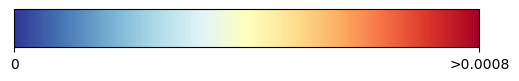

In [ ]:
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap_name),
    cax=ax,
    orientation="horizontal",
    ticks=[vmin, vmax]
)

cbar.ax.set_xticklabels(["0", f">{vmax:.4f}"])

plt.show()

In [ ]:
fig.savefig("color.png", dpi=300, bbox_inches="tight", facecolor="white")